In [34]:
import os
import sys
import time
import logging
import datetime
import glob
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from io import StringIO
from Bio import Entrez
from Bio.Seq import Seq
import requests
import time
import random
import subprocess

#### Helper functions

In [ ]:
# run external command
def run(cmd, outfile=None, check=True):
    """run external command"""
    cmd = [str(c) for c in cmd]
    log.info("$ " + " ".join(cmd) + (f"  > {outfile}" if outfile else ""))
    if outfile:
        with open(outfile, "w") as fh:
            res = subprocess.run(cmd, stdout=fh, stderr=subprocess.PIPE, text=True)
    else:
        res = subprocess.run(cmd, capture_output=True, text=True)
    err = (res.stderr or "").strip()
    if err:
        log.info(err[:1500])
    if res.returncode != 0:
        log.error(f"failed rc = {res.returncode}: {''.join(cmd)}")
        if check:
            raise RuntimeError(f"command failed: {' '.join(cmd)}")
    return res

In [ ]:
# logging
LOG_PATH = WD / "logs" / "v2r-phmm.log"
logging.basicConfig(
    level = logging.INFO,
    format = "%(asctime)s | %(levelname)s | %(message)s",
    handlers = [
        logging.FileHandler(LOG_PATH),
        logging.StreamHandler(sys.stdout)
    ],
    force = True,
)
log = logging.getLogger("v2r-phmm")
log.info(f"---v2r phmm seed collection | {datetime.datetime.now().isoformat()}---")
log.info(f"working directory : {WD}")


2026-05-22 17:00:36,263 | INFO | ---v2r phmm seed collection | 2026-05-22T17:00:36.263447---
2026-05-22 17:00:36,264 | INFO | working directory : /hpcfs/users/a1864358/sanders_lab/v2r_hmm


## Seed curation

In [ ]:
Entrez.email = "13billy.trim13@gmail.com"
"""dont hardcode"""
# Entrez.api_key = os.environ["NCBI_API_KEY"]  
SLEEP = 0.34

WD = Path("/hpcfs/users/a1864358/sanders_lab/v2r_hmm")

In [ ]:
def ncbi_fetch(query, db="protein", batch_size=500, source_tag=None):
    # fetch ncbi protein sequences
    # returns list of SeqRecord
    handle = Entrez.esearch(db=db, term=query, usehistory="y")
    record = Entrez.read(handle)
    handle.close()
    time.sleep(SLEEP)
    count = int(record["Count"])
    webenv = record["WebEnv"]
    query_key = record["QueryKey"]
    log.info(f"found {count} records for {query}")
    
    if count == 0:
        log.warning(f"no records found for {query}")
        return []

    seqs = []
    for start in range(0, count, batch_size):
        time.sleep(SLEEP)
        handle = Entrez.efetch(
            db = db,
            rettype = "fasta",
            retmode = "text",
            retstart = start,
            retmax = batch_size,
            webenv = webenv,
            query_key = query_key,
        )
        batch = list(SeqIO.parse(handle, "fasta"))
        handle.close()
        seqs.extend(batch)
        log.info(f"fetched {len(batch)} sequences")
    
    if source_tag:
        for s in seqs:
            s.description = s.description.rstrip() + f"[source = {source_tag}]"
    
    log.info(f"-> {len(seqs)} sequences fetched for source={source_tag}")
    return seqs

In [ ]:
def fetch_uniprot(url, source_tag, len_min=700, len_max=1200, timeout=120):
    # Fetch fasta from UniProt rest stream, apply length filter, tag source
    log.info(f"  Fetching: {url}")
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()

    seqs = list(SeqIO.parse(StringIO(r.text), "fasta"))
    log.info(f"  Raw sequences: {len(seqs)}")

    seqs = [s for s in seqs if len_min <= len(s.seq) <= len_max]
    log.info(f"  After length filter ({len_min}–{len_max} aa): {len(seqs)}")

    for s in seqs:
        s.description = s.description.rstrip() + f" [source={source_tag}]"
    return seqs


def dedup_extend(target, seen, batch):
    added = 0
    for s in batch:
        if s.id not in seen:
            target.append(s)
            seen.add(s.id)
            added += 1
    return added


def ncbi_fetch_multi(queries, source_tag):
    seqs, seen = [], set()
    for label, q in queries:
        log.info(f"  subquery: {label}")
        batch = ncbi_fetch(q, source_tag=source_tag)
        added = dedup_extend(seqs, seen, batch)
        log.info(f"  added {added} unique sequences from subquery")
    return seqs


def merge_by_seqhash(*seq_lists):
    # dedup across NCBI/UniProt (different accessions, same protein)
    import hashlib

    seen, out = set(), []
    for seqs in seq_lists:
        for s in seqs:
            key = hashlib.md5(str(s.seq).upper().encode()).hexdigest()
            if key not in seen:
                seen.add(key)
                out.append(s)
    return out

In [ ]:
LEN_MIN, LEN_MAX = 700, 1200
SLEN = f"{LEN_MIN}:{LEN_MAX}[SLEN]"

In [ ]:
MOUSE_QUERIES = [
    (
        "Mouse Vmn2r* gene RefSeq",
        f'Vmn2r*[Gene Name] AND "Mus musculus"[Organism] AND RefSeq[Filter] AND {SLEN}',
    ),
    (
        "Mouse vomeronasal type-2 title",
        f'"vomeronasal type-2" AND "Mus musculus"[Organism] AND {SLEN}',
    ),
]
log.info("--- source 1: mouse Vmn2r =")
mouse_seqs = ncbi_fetch_multi(MOUSE_QUERIES, source_tag="mouse_vmn2r")
log.info(f"mouse total unique: {len(mouse_seqs)} sequences")

RAT_QUERIES = [
    (
        "Rat Vom2r* gene RefSeq",
        f'Vom2r*[Gene] AND "Rattus norvegicus"[Organism] AND RefSeq[Filter] AND {SLEN}',
    ),
    (
        "Rat vomeronasal type-2 title",
        f'"vomeronasal type-2" AND "Rattus norvegicus"[Organism] AND {SLEN}',
    ),
]
log.info("--- source 2: rat Vom2r =")
rat_seqs = ncbi_fetch_multi(RAT_QUERIES, source_tag="rat_vom2r")
log.info(f"rat total unique: {len(rat_seqs)} sequences")

UNIPROT_REVIEWED_URL = (
    "https://rest.uniprot.org/uniprotkb/stream"
    "?query=protein_name%3A%22vomeronasal+type+2+receptor%22+AND+reviewed%3Atrue"
    "&format=fasta"
    "&compressed=false"
)
log.info("--- source 4: UniProt Swiss-Prot reviewed V2Rs =")
uniprot_reviewed = fetch_uniprot(
    UNIPROT_REVIEWED_URL,
    source_tag="uniprot_reviewed",
    len_min=LEN_MIN,
    len_max=LEN_MAX,
)
log.info(f"UniProt reviewed: {len(uniprot_reviewed)} sequences")

SQUAMATA_QUERIES = [
    (
        "Squamata Vmn2r* gene",
        f"txid8509[Organism] AND Vmn2r*[Gene Name] AND {SLEN}",
    ),
    (
        "Squamata vomeronasal type-2 title",
        f'txid8509[Organism] AND "vomeronasal type-2"[Title] AND {SLEN}',
    ),
]
log.info("--- source 5a: Squamata NCBI =")
squamata_ncbi = ncbi_fetch_multi(SQUAMATA_QUERIES, source_tag="squamata_ncbi")
log.info(f"squamata NCBI total unique: {len(squamata_ncbi)}")

UNIPROT_SQUAMATA_URL = (
    "https://rest.uniprot.org/uniprotkb/stream"
    "?query=taxonomy_id%3A8509+AND+protein_name%3A%22vomeronasal+type+2+receptor%22"
    "&format=fasta"
    "&compressed=false"
)
UNIPROT_SQUAMATA_IPR_URL = (
    "https://rest.uniprot.org/uniprotkb/stream"
    "?query=taxonomy_id%3A8509+AND+xref%3Ainterpro-IPR004073"
    "&format=fasta"
    "&compressed=false"
)
UNIPROT_SQUAMATA_PFAM_URL = (
    "https://rest.uniprot.org/uniprotkb/stream"
    "?query=taxonomy_id%3A8509+AND+(xref%3Apfam-PF01094+AND+xref%3Apfam-PF00003)"
    "&format=fasta"
    "&compressed=false"
)
log.info("--- source 5b: Squamata UniProt =")
squamata_uniprot_name = fetch_uniprot(
    UNIPROT_SQUAMATA_URL,
    source_tag="squamata_uniprot_name",
    len_min=LEN_MIN,
    len_max=LEN_MAX,
)
squamata_uniprot_ipr = fetch_uniprot(
    UNIPROT_SQUAMATA_IPR_URL,
    source_tag="squamata_uniprot_ipr",
    len_min=LEN_MIN,
    len_max=LEN_MAX,
)
squamata_uniprot_pfam = fetch_uniprot(
    UNIPROT_SQUAMATA_PFAM_URL,
    source_tag="squamata_uniprot_pfam",
    len_min=LEN_MIN,
    len_max=LEN_MAX,
)
log.info(f"squamata UniProt (protein_name): {len(squamata_uniprot_name)}")
log.info(f"squamata UniProt (IPR004073): {len(squamata_uniprot_ipr)}")
log.info(f"squamata UniProt (dual Pfam): {len(squamata_uniprot_pfam)}")
log.info(f"squamata total unique : {sum(len(v) for v in (squamata_ncbi, squamata_uniprot_name, squamata_uniprot_ipr, squamata_uniprot_pfam))}")

UNIPROT_XENOPUS_URL = (
    "https://rest.uniprot.org/uniprotkb/stream"
    "?query=taxonomy_id%3A8355+AND+protein_name%3A%22vomeronasal+type+2+receptor%22"
    "&format=fasta"
    "&compressed=false"
)
log.info("--- source 7: Xenopus tropicalis outgroup =")
xenopus_seqs = fetch_uniprot(
    UNIPROT_XENOPUS_URL,
    source_tag="xenopus_v2r",
    len_min=LEN_MIN,
    len_max=LEN_MAX,
)
log.info(f"Xenopus outgroup: {len(xenopus_seqs)} sequences")

# summary
seed_sources = {
    "mouse_vmn2r": mouse_seqs,
    "rat_vom2r": rat_seqs,
    "uniprot_reviewed": uniprot_reviewed,
    "squamata_ncbi": squamata_ncbi,
    "squamata_uniprot_name": squamata_uniprot_name,
    "squamata_uniprot_ipr": squamata_uniprot_ipr,
    "squamata_uniprot_pfam": squamata_uniprot_pfam,
    "xenopus_v2r": xenopus_seqs,
}
for name, seqs in seed_sources.items():
    log.info(f"  {name}: {len(seqs)}")
log.info(f"Total raw (with cross-source duplicates): {sum(len(v) for v in seed_sources.values())}")


2026-05-22 17:00:36,339 | INFO | ── Source 1: Mouse Vmn2r ──
2026-05-22 17:00:36,340 | INFO |   Subquery: Mouse Vmn2r* gene RefSeq


2026-05-22 17:00:38,340 | INFO | found 202 records for Vmn2r*[Gene Name] AND "Mus musculus"[Organism] AND RefSeq[Filter] AND 700:1200[SLEN]
2026-05-22 17:00:41,361 | INFO | fetched 202 sequences
2026-05-22 17:00:41,362 | INFO | -> 202 sequences fetched for source=mouse_vmn2r
2026-05-22 17:00:41,362 | INFO |   Added 202 unique sequences from subquery
2026-05-22 17:00:41,363 | INFO |   Subquery: Mouse vomeronasal type-2 title
2026-05-22 17:00:43,090 | INFO | found 320 records for "vomeronasal type-2" AND "Mus musculus"[Organism] AND 700:1200[SLEN]


KeyboardInterrupt: 

In [ ]:
# combine, dedup, write raw combined FASTA
    # dedup only by accession ID @ this stage

all_sources = {
    "mouse_vmn2r": mouse_seqs,
    "rat_vom2r": rat_seqs,
    "uniprot_reviewed": uniprot_reviewed,
    "squamata_ncbi": squamata_ncbi,
    "squamata_uniprot_name": squamata_uniprot_name,
    "squamata_uniprot_ipr": squamata_uniprot_ipr,
    "squamata_uniprot_pfam": squamata_uniprot_pfam,
    "xenopus_v2r": xenopus_seqs,
}

# merge + dedup by accession
combined = []
seen_ids = set()
for src, seqs in all_sources.items():
    added = 0
    for s in seqs:
        if s.id not in seen_ids:
            combined.append(s)
            seen_ids.add(s.id)
            added += 1
    log.info(f" after dedup: +{added} unique from {src}")
log.info(f"Total unique: {len(combined)}")

# write 
RAW_OUT = WD / "raw" / "01_seeds_combined_raw.fasta"
SeqIO.write(combined, RAW_OUT, "fasta")
log.info(f"Wrote raw combined fasta to {RAW_OUT} ({RAW_OUT.stat().st_size // 1024} KB)")

print(f" total sequence : {len(combined)}")
print(f" written to {RAW_OUT} ({RAW_OUT.stat().st_size // 1024} KB)")

2026-05-18 22:17:13,503 | INFO |  after dedup: +332 unique from mouse_vmn2r
2026-05-18 22:17:13,537 | INFO |  after dedup: +200 unique from rat_vom2r
2026-05-18 22:17:13,537 | INFO |  after dedup: +3 unique from uniprot_reviewed
2026-05-18 22:17:13,537 | INFO |  after dedup: +49 unique from squamata_ncbi
2026-05-18 22:17:13,538 | INFO |  after dedup: +689 unique from squamata_uniprot_name
2026-05-18 22:17:13,539 | INFO |  after dedup: +1295 unique from squamata_uniprot_ipr
2026-05-18 22:17:13,540 | INFO |  after dedup: +401 unique from squamata_uniprot_pfam
2026-05-18 22:17:13,540 | INFO |  after dedup: +75 unique from xenopus_v2r
2026-05-18 22:17:13,541 | INFO | Total unique: 3044
2026-05-18 22:17:13,560 | INFO | Wrote raw combined FASTA to /hpcfs/users/a1864358/sanders_lab/v2r_hmm/raw/01_seeds_combined_raw.fasta (2964 KB)
 total sequence : 3044
 written to /hpcfs/users/a1864358/sanders_lab/v2r_hmm/raw/01_seeds_combined_raw.fasta (2964 KB)


In [ ]:
!seqkit stats ./raw/01_seeds_combined_raw.fasta

file                               format  type     num_seqs    sum_len  min_len  avg_len  max_len
./raw/01_seeds_combined_raw.fasta  FASTA   Protein     3,044  2,551,807      700    838.3    1,200


### 'Decoy' genes

- to address cross-reactivity with closely related genes
- v2rs = class C GPCRs, which share unique + conserved structure -> decoys share sequence similarity
    - venus flytrap domain (VFD): extracellular domain that binds ligands
    - cysteine rich domain (CRD): connects VFD -> membrane
    - 7 transmembrane domain (7TM): spans cell membrane

**TAS1R_** = taste receptor type-1 ; have similar VFD
**CASR** = calcium sensing receptor ; Class C + VFD + 7TM
**GRM_** = metabotropic glutamate receptors; most abundant GPCR in vertebrates (neurotransmitters in brain) ; highly conserved
**GABBR_** = GABA-B receptors; inhibitory neurotransmitter receptors ; 7TM
**GPCR5/6_** = orphan class C GPCRs; similar structure to taste/calcium receptors

=> if candidate matches decoy almost as well as V2R -> rejected
    -> Gathering threshold = run the curated V2R HMM against decoy database -> identifies highest scoring decoy = best false positive -> `GA floor = max(decoy_bitscore) + buffer`

In [ ]:
"""
decoy panel
    > pull from uniprot swiss-prot reviewed
    > for:
        > seed filtering: drop candidate seed unless
              hmmscan_bitscore(seed) - hmmscan_bitscore(best_decoy) >= MARGIN_BITS
              (min separation from hard negatives; rejects ambiguous hits)
        > post-build threshold calibration: GA floor = max(decoy_bitscore) + buffer
              (gathering threshold must sit above the strongest decoy)
    targets:
        > TAS1R1:3
        > CASR
        > GRM1:8
        > GABBR1 & GABBR2
        > GPRC5A, GPRC5B, GPRC6A
"""

DECOY_GENES = [
    "TAS1R1",
    "TAS1R2",
    "TAS1R3",
    "CASR",
    "GRM1",
    "GRM2",
    "GRM3",
    "GRM4",
    "GRM5",
    "GRM6",
    "GRM7",
    "GRM8",
    "GABBR1",
    "GABBR2",
    "GPRC5A",
    "GPRC5B",
    "GPRC6A",    
]

DECOY_ORGS = [
    '"Mus musculus"[Organism]',
    '"Homo sapiens"[Organism]',
]

decoy_seqs = []
decoy_seen = set()

for gene in DECOY_GENES:
    for org in DECOY_ORGS:
        query = f"{gene} AND {org} AND RefSeq[Filter]"
        log.info(f"fetching decoy sequences for {gene} in {org}")
        batch = ncbi_fetch(query, source_tag="decoy")
        for s in batch:
            if s.id not in decoy_seen:  
                decoy_seqs.append(s)
                decoy_seen.add(s.id)

log.info(f"Total decoy sequences: {len(decoy_seqs)}")

# write decoy panel
decoy_out = WD / "raw" / "02_decoy_sequences.fasta"
SeqIO.write(decoy_seqs, decoy_out, "fasta")
log.info(f"Wrote decoy panel to {decoy_out} ({decoy_out.stat().st_size // 1024} KB)")

2026-05-18 22:17:13,893 | INFO | Fetching decoy sequences for TAS1R1 in "Mus musculus"[Organism]
2026-05-18 22:17:15,085 | INFO | found 5 records for TAS1R1 AND "Mus musculus"[Organism] AND RefSeq[Filter]
2026-05-18 22:17:16,330 | INFO | fetched 5 sequences
2026-05-18 22:17:16,330 | INFO | -> 5 sequences fetched for source=decoy
2026-05-18 22:17:16,331 | INFO | Fetching decoy sequences for TAS1R1 in "Homo sapiens"[Organism]
2026-05-18 22:17:17,393 | INFO | found 6 records for TAS1R1 AND "Homo sapiens"[Organism] AND RefSeq[Filter]
2026-05-18 22:17:18,866 | INFO | fetched 6 sequences
2026-05-18 22:17:18,867 | INFO | -> 6 sequences fetched for source=decoy
2026-05-18 22:17:18,867 | INFO | Fetching decoy sequences for TAS1R2 in "Mus musculus"[Organism]
2026-05-18 22:17:20,101 | INFO | found 2 records for TAS1R2 AND "Mus musculus"[Organism] AND RefSeq[Filter]
2026-05-18 22:17:21,009 | INFO | fetched 2 sequences
2026-05-18 22:17:21,009 | INFO | -> 2 sequences fetched for source=decoy
2026-05

In [ ]:
LOG="/hpcfs/users/a1864358/sanders_lab/v2r_hmm/logs/v2r-phmm.log"
!seqkit stats ./raw/02_decoy_sequences.fasta >> $LOG
!seqkit stats ./raw/01_seeds_combined_raw.fasta >> $LOG

- length filter >700aa
- remove duplicates
- cd hit @ 90%

In [ ]:
%%bash

WD="/hpcfs/users/a1864358/sanders_lab/v2r_hmm"
LOG="/hpcfs/users/a1864358/sanders_lab/v2r_hmm/logs/v2r-phmm.log"

# length filter
seqkit seq --min-len 700 --max-len 1600 \
    --remove-gaps \
    $WD/raw/01_seeds_combined_raw.fasta \
    > $WD/filtered/02_seeds_length_filtered.fasta

N=$(grep -c "^>" $WD/filtered/02_seeds_length_filtered.fasta)
seqkit stats -a $WD/filtered/02_seeds_length_filtered.fasta >> $LOG
M=$(grep -c "^>" $WD/raw/01_seeds_combined_raw.fasta)
echo "Before length filter (700-1600 aa): $M" >> $LOG
echo "After length filter (700-1600 aa): $N" >> $LOG
echo "$(date)" >> $LOG

# dedup
N_PRIOR=$(grep -c "^>" $WD/filtered/02_seeds_length_filtered.fasta)
seqkit rmdup -s \
    $WD/filtered/02_seeds_length_filtered.fasta \
    > $WD/filtered/03_seeds_deduped.fasta

N=$(grep -c "^>" $WD/filtered/03_seeds_deduped.fasta)
seqkit stats -a $WD/filtered/03_seeds_deduped.fasta >> $LOG
echo "After dedup: $N" >> $LOG
echo "$(date)" >> $LOG

# cd-hit
cd-hit \
    -i $WD/filtered/03_seeds_deduped.fasta \
    -o $WD/filtered/04_seeds_cdhit.fasta \
    -c 0.90 \
    -M 0 \
    -T 24

N=$(grep -c "^>" $WD/filtered/04_seeds_cdhit.fasta)
seqkit stats -a $WD/filtered/04_seeds_cdhit.fasta >> $LOG
echo "After cd-hit: $N" >> $LOG
echo "$(date)" >> $LOG  

seqkit stats -a $WD/filtered/04_seeds_cdhit.fasta >> $LOG
N=$(grep -c "^>" $WD/filtered/04_seeds_cdhit.fasta)
MIN=$(seqkit stats -T $WD/filtered/04_seeds_cdhit.fasta | awk 'NR==2{print $6}')
MAX=$(seqkit stats -T $WD/filtered/04_seeds_cdhit.fasta | awk 'NR==2{print $7}')
echo "N=$N, min=$MIN, max=$MAX" >> $LOG
echo "$(date)" >> $LOG

[INFO] 49 duplicated records removed


Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: cd-hit -i
         /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/03_seeds_deduped.fasta
         -o
         /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/04_seeds_cdhit.fasta
         -c 0.90 -M 0 -T 24

Started: Fri May 22 16:58:00 2026
                            Output                              
----------------------------------------------------------------
total seq: 2995
longest and shortest : 1200 and 700
Total letters: 2509927
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 2M
Buffer          : 24 X 16M = 391M
Table           : 2 X 65M = 130M
Miscellaneous   : 0M
Total           : 524M

Table limit with the given memory limit:
Max number of representatives: 491581
Max number of word counting entries: 58326159

# comparing sequences from          0  to        115
---------- new table with       64 representatives
# comparing sequences from        115  to       

## QC + filtering

- pseudogenes
- internal stop codons
- empty seq
- if >2% unknown aa

- strip trailing stop codons
- low quality seq
- remove V2R contaminants from decoy panel (by fasta descriptions)

In [ ]:
def n_seqs(fasta):
    # count seq
    return sum(1 for _ in SeqIO.parse(str(fasta), "fasta"))

"""
QC filter = remove pseudogenes (internal stop codons, empty seq, if >2% unknown (X))
"""
def clean_records(records, max_x_frac=0.02):
    # Drop sequences with internal stops or >2% X. Strip trailing stop.
    out = []
    for r in records:
        s = str(r.seq).rstrip("*")
        if "*" in s:
            continue
        if len(s) == 0 or s.count("X") / len(s) > max_x_frac:
            continue
        r.seq = Seq(s)
        out.append(r)
    return out

In [45]:
# clean + name-based filter

CAND_IN      = WD / "filtered" / "04_seeds_cdhit.fasta"
DECOY_RAW_IN = WD / "raw" / "02_decoy_sequences.fasta"
DEDUP_IN     = WD / "filtered" / "03_seeds_deduped.fasta"
 
CLASS_C_DROP = re.compile(
    r"taste|metabotropic|glutamate\s+receptor|calcium.?sensing|"
    r"\bGABA|GABBR|GPRC5|GPRC6|\bGRM\d|\bCASR\b|TAS1R|mGluR|"
    r"retinoic.acid.induced",
    re.IGNORECASE,
)

DECOY_V2R_CONTAM = re.compile(
    r"Vmn2r|vomeronasal|type-2 vomeronasal|V2R",
    re.IGNORECASE,
)

cands_raw = clean_records(list(SeqIO.parse(str(CAND_IN), "fasta")))
cands_A   = [r for r in cands_raw if not CLASS_C_DROP.search(r.description)]
dropped_A = len(cands_raw) - len(cands_A)
 
decoys_raw = clean_records(list(SeqIO.parse(str(DECOY_RAW_IN), "fasta")))
decoys = [r for r in decoys_raw if not DECOY_V2R_CONTAM.search(r.description)]
dropped_decoys = len(decoys_raw) - len(decoys)
 
log.info(f"Stage A: {len(cands_raw)} clean candidates → {len(cands_A)} kept "
         f"({dropped_A} dropped by name)")
log.info(f"Decoys: {len(decoys_raw)} clean records → {len(decoys)} kept "
         f"({dropped_decoys} V2R contaminants dropped)")
 
STAGE_A_OUT = WD / "filtered" / "05_candidates_stageA.fasta"
SeqIO.write(cands_A, STAGE_A_OUT, "fasta")

DECOY_IN = WD / "filtered" / "02_decoy_sequences_no_v2r.fasta"
SeqIO.write(decoys, DECOY_IN, "fasta")

2026-05-22 17:35:30,479 | INFO | Stage A: 1974 clean candidates → 1888 kept (86 dropped by name)
2026-05-22 17:35:30,533 | INFO | Decoys: 388 clean records → 376 kept (12 V2R contaminants dropped)


376

### bootstrapping
1. define high confidence set (from mouse, rate, uniprot reviewed)
2. CD-HIT : reduce redundance (80%)
3. MSA 
4. build bootstrap HMM


In [62]:
# bootstrap HMM from high-conf v2r core
    # core = mouse + rat + uniprot 

THREADS = 33

CORE_T = re.compile(r"source\s*=\s*(mouse_vmn2r|rat_vom2r|uniprot_reviewed)", re.I)

dedup_recs = clean_records(list(SeqIO.parse(str(DEDUP_IN), "fasta")))
core = [r for r in dedup_recs if CORE_T.search(r.description)]
log.info(f"trusted core seq : {len(core)}")

CORE_FA = WD / "filtered" / "core_v2r.fasta"
SeqIO.write(core, CORE_FA, "fasta")

# reduce redundancy before bootstrap alignment
CORE_REP = WD / "filtered" / "core_v2r_rep.fasta"
run(["cd-hit", "-i", CORE_FA, "-o", CORE_REP, "-c", "0.80", "-n", "5", "-T", THREADS, "-M", "0"])
log.info(f"core representatives: {n_seqs(CORE_REP)}")

# alignment
CORE_ALN = WD / "aligned" / "core_v2r.aln.fasta"
run(["mafft", "--auto", "--thread", THREADS, "--reorder", CORE_REP], outfile=CORE_ALN)

BOOT_HMM = WD / "hmm" / "v2r_bootstraps.hmm"
run(["hmmbuild", "--amino", "--cpu", THREADS, BOOT_HMM, CORE_ALN])

2026-05-22 20:09:35,752 | INFO | trusted core seq : 486
2026-05-22 20:09:35,757 | INFO | $ cd-hit -i /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/core_v2r.fasta -o /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/core_v2r_rep.fasta -c 0.80 -n 5 -T 33 -M 0
2026-05-22 20:09:36,309 | INFO | core representatives: 80
2026-05-22 20:09:36,310 | INFO | $ mafft --auto --thread 33 --reorder /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/core_v2r_rep.fasta  > /hpcfs/users/a1864358/sanders_lab/v2r_hmm/aligned/core_v2r.aln.fasta
2026-05-22 20:09:39,083 | INFO | outputhat23=16
treein = 0
compacttree = 0
stacksize: 8192 kb
rescale = 1
All-to-all alignment.
    0 / 80 (by thread   0) 
   10 / 80 (by thread  16) 
   20 / 80 (by thread   4) 
   30 / 80 (by thread  26) 
   40 / 80 (by thread  11) 
   50 / 80 (by thread  12) 
   60 / 80 (by thread   4) 
   70 / 80 (by thread  11) 
tbfast-pair (aa) Version 7.526
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
33 thread(s)

outputha

CompletedProcess(args=['hmmbuild', '--amino', '--cpu', '33', '/hpcfs/users/a1864358/sanders_lab/v2r_hmm/hmm/v2r_bootstraps.hmm', '/hpcfs/users/a1864358/sanders_lab/v2r_hmm/aligned/core_v2r.aln.fasta'], returncode=0, stdout='# hmmbuild :: profile HMM construction from multiple sequence alignments\n# HMMER 3.4 (Aug 2023); http://hmmer.org/\n# Copyright (C) 2023 Howard Hughes Medical Institute.\n# Freely distributed under the BSD open source license.\n# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -\n# input alignment file:             /hpcfs/users/a1864358/sanders_lab/v2r_hmm/aligned/core_v2r.aln.fasta\n# output HMM file:                  /hpcfs/users/a1864358/sanders_lab/v2r_hmm/hmm/v2r_bootstraps.hmm\n# input alignment is asserted as:   protein\n# number of worker threads:         33\n# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -\n\n# idx name                  nseq  alen  mlen eff_nseq re/pos description\n#---- -------------------- -

In [63]:
def parse_tblout_scores(tbl):
    """Return {target_name: best_full_sequence_bitscore} from hmmsearch --tblout."""
    scores = {}
    with open(tbl) as fh:
        for line in fh:
            if line.startswith("#") or not line.strip():
                continue
            p = line.split()
            tgt, score = p[0], float(p[5])     # col 5 = full-sequence score
            if score > scores.get(tgt, -1e9):
                scores[tgt] = score
    return scores

In [75]:
# score candidates + decoys, set threshold, filter
    # search bootstrap model against cands + decoys
    # keep candidates > strongest decoy

DEVNULL = WD / "logs" / "_hmmsearch_stdout.txt"
TBL_CAND  = WD / "validation" / "stageB_candidates.tbl"
TBL_DECOY = WD / "validation" / "stageB_decoys.tbl"
 
run(["hmmsearch", "--tblout", TBL_CAND,  "--cpu", THREADS, BOOT_HMM, STAGE_A_OUT], outfile=DEVNULL)
run(["hmmsearch", "--tblout", TBL_DECOY, "--cpu", THREADS, BOOT_HMM, DECOY_IN],    outfile=DEVNULL)

cand_scores = parse_tblout_scores(TBL_CAND)
    # cand_scores = dict {sequence_id: bitscore} from parse_tblout_scores
decoy_scores = parse_tblout_scores(TBL_DECOY)

max_decoy = max(decoy_scores.values()) if decoy_scores else 0.0
log.info(f"Candidates with any hit: {len(cand_scores)} / {len(cands_A)}")
log.info(f"Decoy hits: {len(decoy_scores)} | strongest decoy bitscore: {max_decoy:.1f}")

# threshold = must beat strongest decoy: 0=strict
MARGIN = 70.0
KEEP_T = max_decoy - MARGIN

cand_by_id = {r.id: r for r in cands_A} # build dic mapping id to fill seq record
    # cands_A = list of SeqRecord objects passed name filter
kept_ids = [tid for tid, sc in cand_scores.items() if sc >= KEEP_T and tid in cand_by_id]
    # cand_scores.items() = (tid, sc) ... only ID stored not score
kept = [cand_by_id[i] for i in kept_ids]

log.info(f"Stage B keep-threshold (bits): {KEEP_T:.1f}")
log.info(f"Stage B kept: {len(kept)}  (dropped {len(cands_A) - len(kept)} "
         f"as Class C contaminants or non-hits)")

HIGH_CONF_T = max_decoy
GRAY_T = 650 
high_conf = [r for r in cands_A if cand_scores.get(r.id, -1e9) >= HIGH_CONF_T]
gray_zone = [r for r in cands_A if cand_scores.get(r.id, -1e9) < HIGH_CONF_T]
log.info(f"High-confidence candidates: {len(high_conf)}")
log.info(f"Gray-zone candidates: {len(gray_zone)}")



2026-05-22 20:19:07,324 | INFO | $ hmmsearch --tblout /hpcfs/users/a1864358/sanders_lab/v2r_hmm/validation/stageB_candidates.tbl --cpu 33 /hpcfs/users/a1864358/sanders_lab/v2r_hmm/hmm/v2r_bootstraps.hmm /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/05_candidates_stageA.fasta  > /hpcfs/users/a1864358/sanders_lab/v2r_hmm/logs/_hmmsearch_stdout.txt


2026-05-22 20:19:22,619 | INFO | $ hmmsearch --tblout /hpcfs/users/a1864358/sanders_lab/v2r_hmm/validation/stageB_decoys.tbl --cpu 33 /hpcfs/users/a1864358/sanders_lab/v2r_hmm/hmm/v2r_bootstraps.hmm /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/02_decoy_sequences_no_v2r.fasta  > /hpcfs/users/a1864358/sanders_lab/v2r_hmm/logs/_hmmsearch_stdout.txt
2026-05-22 20:19:25,623 | INFO | Candidates with any hit: 1888 / 1888
2026-05-22 20:19:25,624 | INFO | Decoy hits: 292 | strongest decoy bitscore: 795.4
2026-05-22 20:19:25,625 | INFO | Stage B keep-threshold (bits): 725.4
2026-05-22 20:19:25,625 | INFO | Stage B kept: 1683  (dropped 205 as Class C contaminants or non-hits)
2026-05-22 20:19:25,626 | INFO | High-confidence candidates: 1286
2026-05-22 20:19:25,627 | INFO | Gray-zone candidates: 602


- keep threshold = max decoy - 70 bits (to keep divergent positives + stay out of decoy distribution)

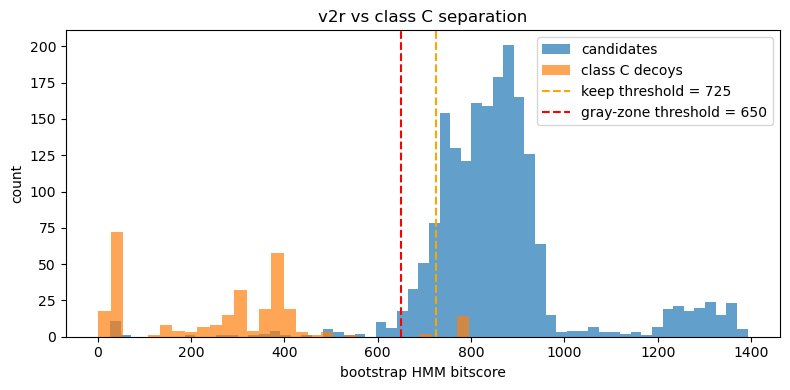

In [77]:
# plot : bimodal candidate distribution vs decoy ceiling
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(list(cand_scores.values()), bins=60, alpha=0.7, label="candidates")
if decoy_scores:
    ax.hist(list(decoy_scores.values()), bins=30, alpha=0.7, label="class C decoys")
ax.axvline(KEEP_T, color="orange", ls="--", label=f"keep threshold = {KEEP_T:.0f}")
ax.axvline(GRAY_T, color="red", ls="--", label=f"gray-zone threshold = {GRAY_T:.0f}")
ax.set_xlabel("bootstrap HMM bitscore"); ax.set_ylabel("count")
ax.set_title("v2r vs class C separation"); ax.legend()
fig.tight_layout()
plt.show()

In [78]:
# re-cluster validated set for seed alignment
SEED_VALIDATED = WD / "filtered" / "06_validated_v2r.fasta"
SEED_REP = WD / "filtered" / "07_seed_reps.fasta"
SeqIO.write(kept, SEED_VALIDATED, "fasta")

run(["cd-hit", "-i", SEED_VALIDATED, "-o", SEED_REP, "-c", "0.80", "-n", "5", "-T", THREADS, "-M", "0"])
n_rep = n_seqs(SEED_REP)
log.info(f"re-clustered seed set: {n_rep} representatives")

2026-05-22 20:23:33,014 | INFO | $ cd-hit -i /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/06_validated_v2r.fasta -o /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/07_seed_reps.fasta -c 0.80 -n 5 -T 33 -M 0


2026-05-22 20:23:34,049 | INFO | re-clustered seed set: 1206 representatives


In [ ]:
# MSA
SEED_ALN = WD / "aligned" / "07_seeds_aln.fasta"

run(["mafft", "--auto", "--thread", THREADS, "--reorder", SEED_REP], outfile=SEED_ALN)

aln_cols = len(next(SeqIO.parse(str(SEED_ALN), "fasta")).seq)
log.info(f"raw alignment columns = {aln_cols}")    "notebook.output.textLineLimit": 75,
    "editor.columnSelection": true

2026-05-22 20:23:38,255 | INFO | $ mafft --localpair --maxiterate 1000 --thread 33 --reorder /hpcfs/users/a1864358/sanders_lab/v2r_hmm/filtered/07_seed_reps.fasta  > /hpcfs/users/a1864358/sanders_lab/v2r_hmm/aligned/07_seeds_aln.fasta
2026-05-22 23:42:29,128 | INFO | outputhat23=16
treein = 0
compacttree = 0
stacksize: 8192 kb
rescale = 1
All-to-all alignment.
    0 / 1206 (by thread   0) 
   10 / 1206 (by thread   7) 
   20 / 1206 (by thread   4) 
   30 / 1206 (by thread  29) 
   40 / 1206 (by thread  32) 
   50 / 1206 (by thread  17) 
   60 / 1206 (by thread  27) 
   70 / 1206 (by thread   1) 
   80 / 1206 (by thread  11) 
   90 / 1206 (by thread   1) 
  100 / 1206 (by thread  17) 
  110 / 1206 (by thread  20) 
  120 / 1206 (by thread   3) 
  130 / 1206 (by thread  13) 
  140 / 1206 (by thread   8) 
  150 / 1206 (by thread   3) 
  160 / 1206 (by thread   7) 
  170 / 1206 (by thread   3) 
  180 / 1206 (by thread   2) 
  190 / 1206 (by thread  21) 
  200 / 1206 (by thread  30) 
  210 /

##### Trim
- to typical v2r length

In [ ]:
# trim + column-count
SEED_TRIM = WD / "aligned" / "08_seeds_trimmed.fasta"
run(["trimal", "-in", SEED_ALN, "-out", SEED_TRIM, "-gt", "0.3"])

trim_cols = len(next(SeqIO.parse(str(SEED_TRIM), "fasta")).seq)
log.info(f"trimmed alignment columns = {trim_cols}")

# full length v2r ~800-900aa
if not (400 <= trim_cols <= 1100):
    log.warning(f"trimmed alignment columns = {trim_cols} (should be 400-1100)")
assert trim_cols >= 400

2026-05-22 23:42:29,154 | INFO | $ trimal -in /hpcfs/users/a1864358/sanders_lab/v2r_hmm/aligned/07_seeds_aln.fasta -out /hpcfs/users/a1864358/sanders_lab/v2r_hmm/aligned/08_seeds_trimmed.fasta -automated1
2026-05-22 23:42:51,557 | INFO | trimmed alignment columns = 454


## Build HMM

In [81]:
# build HMM

HMM = WD / "hmm" / "v2r_full.hmm"
run(["hmmbuild", "--amino", "--cpu", THREADS, HMM, SEED_TRIM])

res = run(["hmmstat", HMM])
stat = None
for line in res.stdout.splitlines():
    if line.startswith("#") or not line.strip():
        continue 
    p = line.split()
    stat = dict(nseq = int(p[3]), eff_nseq = float(p[4]), M = int(p[5]), relent = float(p[6]))
    break
log.info(f"HMM stats: {stat}")
assert stat is not None, "error : could not parse hmmstat output"

M, nseq, effn, relent = stat["M"], stat["nseq"], stat["eff_nseq"], stat["relent"]
ratio = effn / nseq if nseq else 0
log.info(f"Model length M={M} | nseq={nseq} | eff_nseq={effn:.2f} "
         f"(ratio {ratio:.2f}) | re/pos={relent:.3f} bits")

assert 600 <= M <= 1000, f"GATE WARN/FAIL: M={M} outside 600–1000 (full-length V2R ~800)."
assert 0.05 <= ratio <= 0.95, f"GATE FAIL: eff_nseq/nseq={ratio:.2f} degenerate."
assert relent >= 0.55, f"GATE FAIL: re/pos={relent:.3f} < 0.55 bits — weak model."
log.info("CHECKPOINT (hmmstat) PASS")


2026-05-22 23:42:51,566 | INFO | $ hmmbuild --amino --cpu 33 /hpcfs/users/a1864358/sanders_lab/v2r_hmm/hmm/v2r_full.hmm /hpcfs/users/a1864358/sanders_lab/v2r_hmm/aligned/08_seeds_trimmed.fasta
2026-05-22 23:42:52,436 | INFO | $ hmmstat /hpcfs/users/a1864358/sanders_lab/v2r_hmm/hmm/v2r_full.hmm
2026-05-22 23:42:52,467 | INFO | HMM stats: {'nseq': 1206, 'eff_nseq': 1.45, 'M': 428, 'relent': 0.59}
2026-05-22 23:42:52,468 | INFO | Model length M=428 | nseq=1206 | eff_nseq=1.45 (ratio 0.00) | re/pos=0.590 bits


AssertionError: GATE WARN/FAIL: M=428 outside 600–1000 (full-length V2R ~800).

## Threshold calibration
- searching HMM against seeds and decoys
- scoring and calculating gap between seeds and decoys
    - gap = distance between strongest decoy & weakest v2r
- *calcium sensing receptors (casr) + gprc6a = close relatives to v2rs*
    - share extracellular VFD -> gap is negative (divergent v2rs may score lower than high scoring casr/gprc67as)
        - however these will be small in number

In [ ]:
# threshold calibration (valid seeds vs Class-C decoys)
STAGE_B_OUT = WD / "filtered" / "06_validated_v2r.fasta"   # validated Stage-B seeds
TBL_SELF  = WD / "validation" / "final_self.tbl"
TBL_DEC2  = WD / "validation" / "final_decoys.tbl"

run(["hmmsearch", "--tblout", TBL_SELF, "--cpu", THREADS, HMM, STAGE_B_OUT], outfile=DEVNULL)
run(["hmmsearch", "--tblout", TBL_DEC2, "--cpu", THREADS, HMM, DECOY_IN],    outfile=DEVNULL)

self_scores  = parse_tblout_scores(TBL_SELF)
decoy2       = parse_tblout_scores(TBL_DEC2)

min_self   = min(self_scores.values()) if self_scores else 0   # weakest seed
max_decoy2 = max(decoy2.values()) if decoy2 else 0             # strongest decoy
gap        = min_self - max_decoy2
log.info(f"min seed self={min_self:.1f} | max decoy={max_decoy2:.1f} | gap={gap:.1f}")

thresholds = {
    "model_length_M": M,
    "eff_nseq": round(effn, 2),
    "relent": round(relent, 3),
    "n_seed_seqs": len(self_scores),
    "min_seed_self": round(min_self, 1),
    "max_decoy": round(max_decoy2, 1),
    "homology_cutoff_E": 1e-5,
}
THR_OUT = WD / "hmm" / "v2r_thresholds.json"
THR_OUT.write_text(json.dumps(thresholds, indent=2))
log.info(f"Thresholds written: {THR_OUT}")
print(json.dumps(thresholds, indent=2))

## Benchmarking
- against *cyanocinctus (Li et al. 2021)*
    - run search against its proteome
    - parse hits
    - evaluate + segmenting hits
        - E <= 10 (Homology Ceiling): This captures all Class C GPCRs (including standard brain receptors, taste receptors, and V2Rs) in the snake.
        - E <= 1e-5 (Confident V2R family call): Captures highly probable Class C GPCRs.
        - E <= 1e-10 (High confidence): Captures extremely strong matches.

In [ ]:
# benchmark vs H. cyanocinctus
HCYAN_PROTEOME = WD / "validation" / "hcyan_proteins.fasta"
HCYAN_TBL      = WD / "validation" / "hcyan_hits.tbl"

run(["hmmsearch", "--tblout", HCYAN_TBL, "-E", "10",
     "--cpu", THREADS, HMM, HCYAN_PROTEOME], outfile=DEVNULL)

# parse full-seq E-value (col 4) + bitscore (col 5)
def parse_evals(tbl):
    o = {}
    for line in open(tbl):
        if line.startswith("#") or not line.strip():
            continue
        p = line.split(); tid, E, S = p[0], float(p[4]), float(p[5])
        if tid not in o or S > o[tid][1]:
            o[tid] = (E, S)
    return o

hits = parse_evals(HCYAN_TBL)
ceil_E10 = len(hits)
v2r_5    = sum(1 for e, s in hits.values() if e <= 1e-5)
v2r_10   = sum(1 for e, s in hits.values() if e <= 1e-10)
log.info(f"H. cyanocinctus V2R-family hits | E<10: {ceil_E10} | E<1e-5: {v2r_5} | E<1e-10: {v2r_10}")
print(f"H. cyanocinctus V2R-family proteins detected:")
print(f"  E<10    (homology ceiling) : {ceil_E10}")
print(f"  E<1e-5  (confident V2R call): {v2r_5}")
print(f"  E<1e-10 (high-confidence)   : {v2r_10}")
print(f"  ~15-25 of these are non-V2R class C (CaSR/GPRC6A/mGluR/GABBR/taste);")
print(f"  remainder (~{v2r_5-20}) are V2Rs. Recall converged ~460 across model variants.")

#### Benchmarking results

#### 1. Hit Counts & Confidence Tiers
| Tier | E-Value Range | Count | Biological Interpretation |
| :--- | :---: | :---: | :--- |
| **High-Confidence** | $E < 10^{-10}$ | **396** | Intact, canonical, highly-conserved V2Rs |
| **Confident V2R** | $E < 10^{-5}$ | **426** | Confident functional V2R receptor protein calls |
| **Low-Confidence** | $10^{-5} \le E < 10^{-3}$ | **14** | Highly divergent or partial V2R sequences |
| **Class C Homologs** | $10^{-3} \le E < 10$ | **18** | Expected non-V2R Class-C GPCRs (CaSR / mGluRs / GPRC6A / taste) |
| **Total Superfamily** | $E < 10$ | **458** | Total Class-C GPCR homologous superfamily proteins |

---
- **True V2R Protein Count:** Subtracting the ~18 standard vertebrate Class C GPCR decoys, our HMM identifies **≈408 functional V2R proteins** in the snake's proteome.
    - **Pfam** = was only 156 proteins with canonical class C 7TM (`PF00003`) and 153 with VFD (`PF01094`)
- **Genomic vs. Proteome Discrepancy:** While the paper cites $>1000$ V2R genes, that figure may count all pseudogenes, fragments, and non-transcribed loci. This benchmark represents only translated, intact protein-coding ORFs.


## pHMM: genome scan (e.g., of new assemblies)
- scan proteome/genome
    - gets ORFs -> pHMM -> maps hits back to scaffold coordinates + collapses overlapping/adjacent ORF hits into **V2R loci** -> returns locus counts + coordinate table

In [ ]:
# reusable V2R scanners (model = HMM = hmm/v2r_full.hmm)
import re as _re

def parse_evals(tbl):
    """{target: (best_full_seq_Evalue, best_full_seq_bitscore)} from hmmsearch --tblout."""
    o = {}
    for line in open(tbl):
        if line.startswith("#") or not line.strip():
            continue
        p = line.split(); t, E, S = p[0], float(p[4]), float(p[5])
        if t not in o or S > o[t][1]:
            o[t] = (E, S)
    return o

def scan_proteome(pep_fasta, tag, evalue=1e-5, hmm=HMM):
    """Scan an ANNOTATED proteome (.pep/.faa). Returns (confident_hits, all_hits)."""
    pep_fasta = Path(pep_fasta)
    tbl = WD / "validation" / f"{tag}_proteome.tbl"
    run(["hmmsearch", "--tblout", tbl, "-E", "10", "--cpu", THREADS, str(hmm), str(pep_fasta)],
        outfile=DEVNULL)
    allh = parse_evals(tbl)
    conf = {k: v for k, v in allh.items() if v[0] <= evalue}
    log.info(f"[{tag}] proteome scan: {len(allh)} homologs (E<10) | "
             f"{len(conf)} confident V2R (E<{evalue:g})")
    return conf, allh

def _merge_loci(intervals, gap):
    """intervals: [(start,end,strand,score,Evalue)] on ONE scaffold -> merged loci."""
    loci = []
    for s, e, st, sc, ev in sorted(intervals):
        if loci and s <= loci[-1]["end"] + gap:
            L = loci[-1]; L["end"] = max(L["end"], e); L["n_orfs"] += 1
            if sc > L["score"]:
                L.update(score=sc, evalue=ev, strand=st)
        else:
            loci.append(dict(start=s, end=e, strand=st, score=sc, evalue=ev, n_orfs=1))
    return loci

def scan_genome(genome_fasta, tag, minsize=600, evalue=1e-5, merge_gap=10000, hmm=HMM):
    """Scan a RAW nucleotide assembly and count V2R loci.

    minsize   : getorf min ORF length in NT (600=200aa catches the V2R 7TM exon;
                lower to ~300 to also capture short pseudogene fragments).
    evalue    : pHMM full-sequence E-value cutoff for a V2R ORF-hit.
    merge_gap : bp; ORF-hits within this distance on a scaffold collapse to one locus
                (V2R genes are multi-exon; 10 kb groups exons of a gene without usually
                fusing adjacent tandem paralogs — tune per assembly).
    """
    genome_fasta = Path(genome_fasta)
    orf = WD / "validation" / f"{tag}_orfs.faa"
    tbl = WD / "validation" / f"{tag}_orf_hits.tbl"
    csv_out = WD / "validation" / f"{tag}_v2r_loci.csv"

    # surface ORFs (both strands, between stops)
    run(["getorf", "-sequence", str(genome_fasta), "-outseq", str(orf),
         "-minsize", str(minsize), "-find", "1"])
         
    # score ORFs with the pHMM
    run(["hmmsearch", "--tblout", tbl, "-E", "10", "--cpu", THREADS, str(hmm), str(orf)],
        outfile=DEVNULL)
        
    # ORF id -> genomic coords  (header: ">SCAF_N [a - b] (REVERSE SENSE)")
    hdr = _re.compile(r"\[(\d+)\s*-\s*(\d+)\]")
    coord = {}
    
    for rec in SeqIO.parse(str(orf), "fasta"):
        m = hdr.search(rec.description)
        if not m:
            continue
        a, b = int(m.group(1)), int(m.group(2))
        coord[rec.id] = (rec.id.rsplit("_", 1)[0], min(a, b), max(a, b),
                         "-" if "REVERSE SENSE" in rec.description else "+")
                         
    # keep confident ORF-hits, group by scaffold
    hits = parse_evals(tbl)
    byscaf = {}
    
    for oid, (E, S) in hits.items():
        if E <= evalue and oid in coord:
            sc, s, e, st = coord[oid]
            byscaf.setdefault(sc, []).append((s, e, st, S, E))
            
    # merge into loci + write table
    rows, n_orf_hits = [], 0
    
    for sc, ivs in byscaf.items():
        n_orf_hits += len(ivs)
        for L in _merge_loci(ivs, merge_gap):
            rows.append([sc, L["start"], L["end"], L["strand"],
                         L["n_orfs"], f"{L['score']:.1f}", f"{L['evalue']:.1e}"])
                         
    rows.sort(key=lambda r: (r[0], r[1]))
    
    import csv as _csv
    
    with open(csv_out, "w", newline="") as fh:
        w = _csv.writer(fh)
        w.writerow(["scaffold", "start", "end", "strand", "n_orfs", "best_bitscore", "best_evalue"])
        w.writerows(rows)
        
    n_loci = len(rows)
    n_placed = sum(1 for r in rows if str(r[0]).startswith("CM"))
    
    log.info(f"[{tag}] genome scan: {n_orf_hits} confident ORF-hits -> {n_loci} V2R loci "
             f"({n_placed} on assembled chromosomes) | table: {csv_out}")
    print(f"[{tag}] V2R loci = {n_loci}  (ORF-hits={n_orf_hits}, merge_gap={merge_gap} bp, "
          f"minsize={minsize} nt, E<{evalue:g})")
    return n_loci, rows


##### Useage

On annotated assembly:
```python
conf, allh = scan_proteome("path/to/*.pep", tag = "species")
print(len(conf), "confident v2rs")
```
On raw-assembly (no-annotation):
```python
n_loci, loci = scan_genome("/path/*.fa", tag = "species")
# or
n_loci, loci = scan_genome("/.fa", tag = "species", minsize = 300, merge_gap = 8000)
```
-> loci table -> validation/<tag>_v2r_loci.csv : [scaffold/start/end/strand/n_orfs/score/E]